# Economic Risk Score Construction and Validation

This notebook builds a county-level economic risk score using key socioeconomic indicators from the cleaned ACS dataset.

The goal is to combine multiple indicators into one interpretable score, classify counties into risk groups, and validate whether the resulting categories reflect meaningful differences in economic conditions.

In [2]:
# -------------------------------------------------------
# Import Libraries
# -------------------------------------------------------

import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler

## Load Dataset

The cleaned county-level dataset is loaded for risk modeling.

This dataset contains socioeconomic indicators such as income, poverty, unemployment, education, and housing, which will be used to construct the economic risk score.

In [4]:
# -------------------------------------------------------
# Load Dataset
# -------------------------------------------------------

df = pd.read_csv("county_master.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3222, 9)


,county_fips,county_name,total_population,median_household_income,poverty_rate,unemployment_rate,homeownership_rate,renter_rate,bachelors_or_higher_pct
0,1001,"Autauga County, Alabama",59947,72481.0,0.112895,0.022899,0.770607,0.229393,0.291385
1,1003,"Baldwin County, Alabama",246989,78775.0,0.100927,0.030107,0.776036,0.223964,0.336895
2,1005,"Barbour County, Alabama",24643,46042.0,0.213826,0.077736,0.682406,0.317594,0.106273
3,1007,"Bibb County, Alabama",22130,52541.0,0.224570,0.120808,0.791796,0.208204,0.117256
4,1009,"Blount County, Alabama",59518,64190.0,0.128601,0.049971,0.809829,0.190171,0.158182


## Feature Normalization

Before constructing the economic risk score, the selected socioeconomic indicators are normalized using Min-Max scaling.

This scales all variables to a range between 0 and 1, ensuring that each feature contributes equally to the final risk score regardless of its original scale.

In [6]:
# -------------------------------------------------------
# Feature Normalization
# -------------------------------------------------------

risk_features = [
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "homeownership_rate",
    "bachelors_or_higher_pct"
]

scaler = MinMaxScaler()

df_norm = df.copy()
df_norm[risk_features] = scaler.fit_transform(df_norm[risk_features])

df_norm[risk_features].head()

,median_household_income,poverty_rate,unemployment_rate,homeownership_rate,bachelors_or_higher_pct
0,0.339478,0.158661,0.079997,0.801974,0.361822
1,0.377520,0.139429,0.105176,0.807624,0.418334
2,0.179679,0.320850,0.271562,0.710182,0.131963
3,0.218959,0.338116,0.422028,0.824026,0.145601
4,0.289367,0.183900,0.174568,0.842792,0.196420


## Economic Risk Score Construction

A composite economic risk score is created by combining the normalized socioeconomic indicators into a single metric.

Indicators associated with stronger economic conditions (income, homeownership, and education) are inverted so that higher values consistently represent higher economic risk.

The final score is calculated as the average of all five components.

In [8]:
# -------------------------------------------------------
# Economic Risk Score
# -------------------------------------------------------

df_norm["economic_risk_score"] = (
    (1 - df_norm["median_household_income"]) +
    df_norm["poverty_rate"] +
    df_norm["unemployment_rate"] +
    (1 - df_norm["homeownership_rate"]) +
    (1 - df_norm["bachelors_or_higher_pct"])
) / 5

df_norm[["county_name", "economic_risk_score"]].head()

,county_name,economic_risk_score
0,"Autauga County, Alabama",0.347077
1,"Baldwin County, Alabama",0.328225
2,"Barbour County, Alabama",0.514118
3,"Bibb County, Alabama",0.514312
4,"Blount County, Alabama",0.405978


## Risk Category Assignment

To simplify interpretation, counties are grouped into three categories based on their economic risk score:

- Low Risk  
- Medium Risk  
- High Risk  

Quantile-based binning is used to divide counties into equally sized groups.

In [10]:
# -------------------------------------------------------
# Risk Category Assignment
# -------------------------------------------------------

df_norm["risk_category"] = pd.qcut(
    df_norm["economic_risk_score"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

df_norm["risk_category"].value_counts()

risk_category
Low Risk       1074
Medium Risk    1074
High Risk      1074
Name: count, dtype: int64

## Attach Risk Labels to Dataset

The computed economic risk score and corresponding risk category are merged back into the main dataset.

This allows each county to be analyzed using both its original socioeconomic indicators and its overall risk classification.

In [12]:
# -------------------------------------------------------
# Merge Risk Labels into Main Dataset
# -------------------------------------------------------

df = df.merge(
    df_norm[["county_fips", "economic_risk_score", "risk_category"]],
    on="county_fips",
    how="left"
)

df[["county_name", "economic_risk_score", "risk_category"]].head()

,county_name,economic_risk_score,risk_category
0,"Autauga County, Alabama",0.347077,Low Risk
1,"Baldwin County, Alabama",0.328225,Low Risk
2,"Barbour County, Alabama",0.514118,High Risk
3,"Bibb County, Alabama",0.514312,High Risk
4,"Blount County, Alabama",0.405978,Medium Risk


## Risk Category Distribution

This section examines how counties are distributed across the three economic risk categories.

Visualizing this distribution helps confirm whether the classification is balanced and suitable for comparison.

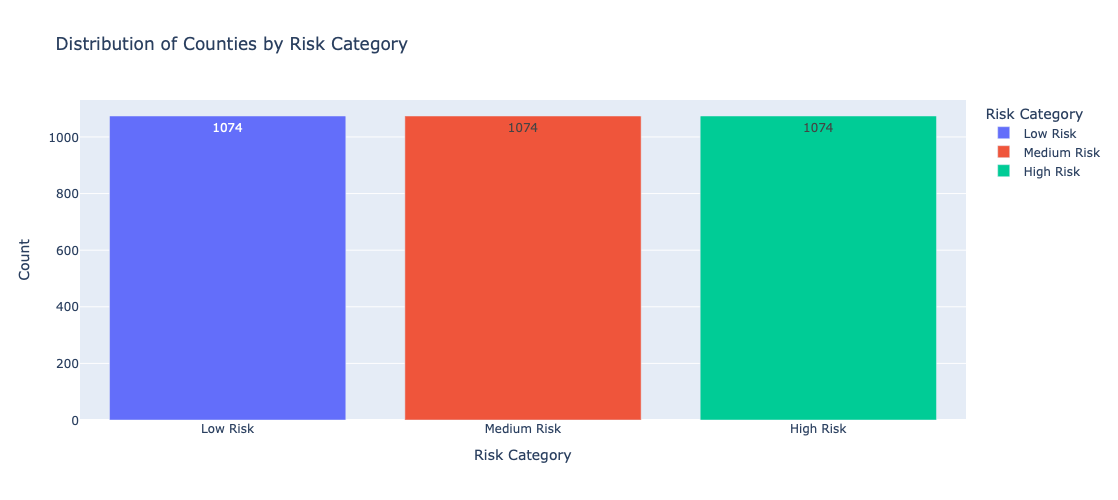

In [14]:
# -------------------------------------------------------
# Risk Category Distribution
# -------------------------------------------------------

import plotly.express as px

risk_counts = df["risk_category"].value_counts().reset_index()
risk_counts.columns = ["Risk Category", "Count"]

fig = px.bar(
    risk_counts,
    x="Risk Category",
    y="Count",
    color="Risk Category",
    text="Count",
    title="Distribution of Counties by Risk Category"
)

fig.update_layout(width=700, height=500)

fig.show()

## Bar Chart of Average Economic Indicators by Risk Category

To validate the effectiveness of the economic risk score, we compare the average values of key socioeconomic indicators across each risk category.

If the scoring method is meaningful, we expect:

- High Risk counties → lower income, higher poverty, higher unemployment  
- Low Risk counties → higher income, lower poverty, lower unemployment  

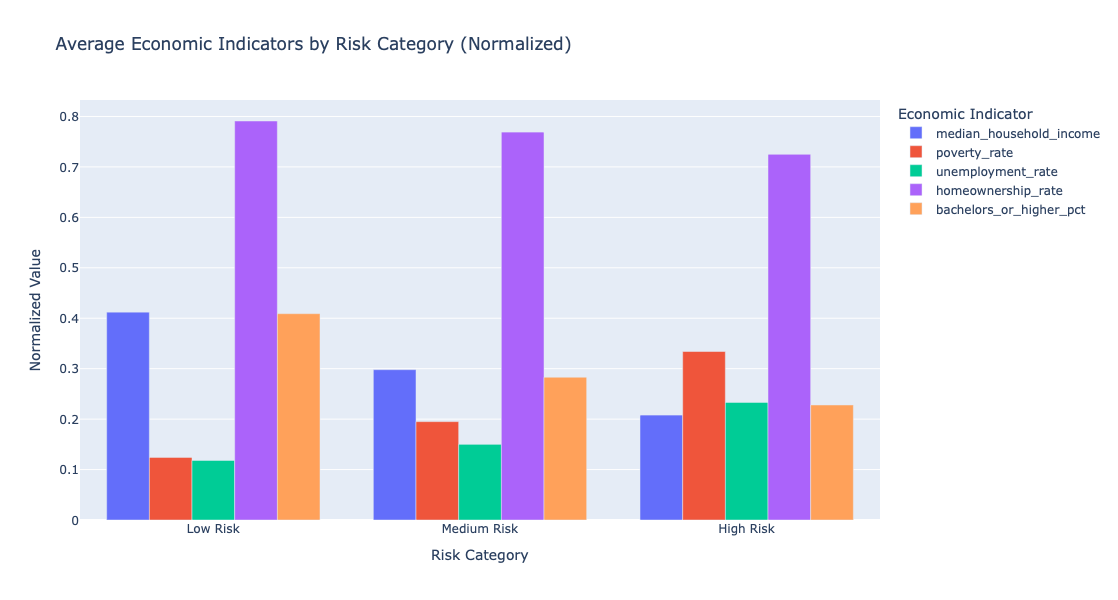

In [16]:
# -------------------------------------------------------
# Bar Chart: Mean Economic Indicators by Risk Category (Normalized)
# -------------------------------------------------------

risk_profile_norm = (
    df_norm.groupby("risk_category", observed=False)[[
        "median_household_income",
        "poverty_rate",
        "unemployment_rate",
        "homeownership_rate",
        "bachelors_or_higher_pct"
    ]]
    .mean()
    .round(3)
)

risk_profile_reset = risk_profile_norm.reset_index()

risk_profile_long = risk_profile_reset.melt(
    id_vars="risk_category",
    var_name="Indicator",
    value_name="Value"
)

fig = px.bar(
    risk_profile_long,
    x="risk_category",
    y="Value",
    color="Indicator",
    barmode="group",
    title="Average Economic Indicators by Risk Category (Normalized)",
    labels={
        "risk_category": "Risk Category",
        "Value": "Normalized Value",
        "Indicator": "Economic Indicator"
    },
    category_orders={"risk_category": ["Low Risk", "Medium Risk", "High Risk"]}
)

fig.update_layout(width=1000, height=600)

fig.show()

## Economic Risk Score Distribution by Category

This plot shows how the economic risk score is distributed within each risk category.

It helps confirm whether the categories are clearly separated and whether the scoring method produces meaningful group differences.

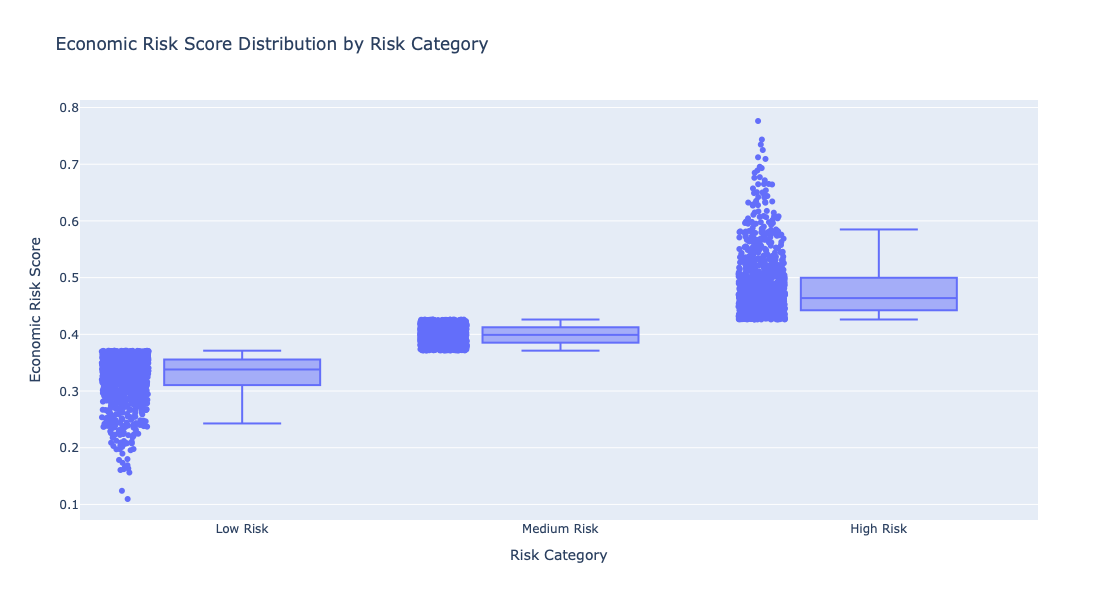

In [18]:
# -------------------------------------------------------
# Economic Risk Score Distribution by Risk Category
# -------------------------------------------------------

import plotly.express as px

fig = px.box(
    df,
    x="risk_category",
    y="economic_risk_score",
    points="all",
    category_orders={"risk_category": ["Low Risk", "Medium Risk", "High Risk"]},
    title="Economic Risk Score Distribution by Risk Category",
    labels={
        "risk_category": "Risk Category",
        "economic_risk_score": "Economic Risk Score"
    }
)

fig.update_layout(
    width=800,
    height=600
)

fig.show()

### Observations

The boxplot shows a clear separation in economic risk scores across the three categories.

- Low Risk counties have consistently lower scores
- Medium Risk counties fall within a narrow middle range
- High Risk counties have higher scores with greater variability

There is minimal overlap between categories, indicating that the classification is well-defined and meaningful.

This analysis supports:

**Which U.S. counties are at the highest risk of economic decline based on the constructed economic risk score?**

### Observations

The normalized bar chart clearly shows consistent trends across all economic indicators:

- Median household income, education, and homeownership decrease as risk increases
- Poverty and unemployment increase as risk increases

These consistent patterns across all variables confirm that the economic risk score effectively captures differences in county-level economic conditions.

Using normalized values allows for a fair comparison between indicators that originally had different scales.

This analysis addresses:

**How do income, poverty, unemployment, education, and homeownership together influence a county's economic risk?**

In [21]:
# -------------------------------------------------------
# Save Final Dataset with Risk Scores and Categories
# -------------------------------------------------------

final_cols = [
    "county_fips",
    "county_name",
    "total_population",
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "homeownership_rate",
    "renter_rate",
    "bachelors_or_higher_pct",
    "economic_risk_score",
    "risk_category"
]

df_final = df[final_cols]

df_final.to_csv("county_risk_scored.csv", index=False)

print("Saved file: county_risk_scored.csv")
print("Final shape:", df_final.shape)

Saved file: county_risk_scored.csv
Final shape: (3222, 11)


## Conclusion

This project successfully identified U.S. counties at risk of economic decline by combining multiple socioeconomic indicators into a single economic risk score.

Key findings include:

- Strong relationships exist between income, poverty, unemployment, and education
- Counties with lower income and education tend to have higher poverty and unemployment
- The constructed risk score effectively captures these relationships
- Risk categories show clear and meaningful differences across indicators

Overall, this approach demonstrates how public data can be transformed into actionable insights to better understand economic conditions across regions.

## Limitations

- The analysis is based on aggregated county-level data, which may hide local variations
- The risk score assumes equal weighting of all indicators
- Temporal trends are not considered (static snapshot of data)

## Future Work

- Incorporate time-series data to track economic trends over time
- Apply machine learning models to predict future economic risk
- Build an interactive dashboard for real-time exploration of county-level risk